# SHAP Analysis — Diabetes Risk Model

This notebook runs SHAP explainability analysis across all three trained models: 

- Decision Tree 
- Random Forest 
- XGBoost  

For each model it produces:

- **Summary plot** — beeswarm of SHAP values across the evaluation set
- **Bar plot** — mean |SHAP| feature importance
- **Waterfall plot** — local explanation for a single prediction
- **Feature importance CSV** — exportable ranking table

## 1. Imports & Configuration

In [1]:
from __future__ import annotations

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

shap.initjs()

In [2]:
# ── Path configuration ──────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve().parents[0]
DATA_DIR      = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR    = ARTIFACTS_DIR / "models"
ASSETS_DIR    = PROJECT_ROOT / "assets"

ASSETS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── Model registry ──────────────────────────────────────────────────────────
MODEL_FILES = {
    "decision_tree": "decision_tree.pkl",
    "random_forest": "random_forest.pkl",
    "xgboost":       "xgboost.pkl",
}
MODEL_LABELS = {
    "decision_tree": "DecisionTree",
    "random_forest": "RandomForest",
    "xgboost":       "XGBoost",
}

ALL_MODELS = ["decision_tree", "random_forest", "xgboost"]

# ── Run parameters ----------───────────────────────────────────────────────
BACKGROUND_SIZE  = 500         # rows from X_train used as SHAP background
EVALUATION_SIZE  = 1000        # rows from X_test to explain
MAX_DISPLAY      = 15          # max features shown in plots
RANDOM_STATE     = 42
WATERFALL_INDEX  = 0           # which evaluation row to use for the local plot
SKIP_WATERFALL   = False

print("Configuration. Models to run:", ALL_MODELS)

Configuration. Models to run: ['decision_tree', 'random_forest', 'xgboost']


## 2. Helper Functions

In [3]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing: {path}. Run prepare_data.py, preprocess_data.py, and train_models.py first."
        )
    return path


def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)


def sample_frame(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if n <= 0 or n >= len(df):
        return df.copy()
    return df.sample(n=n, random_state=seed).copy()


def compute_shap_values(explainer, X_eval: pd.DataFrame):
    try:
        explanation  = explainer(X_eval, check_additivity=False)
        values       = np.asarray(explanation.values)
        base_values  = np.asarray(explanation.base_values)
    except TypeError:
        legacy = explainer.shap_values(X_eval, check_additivity=False)
        values = np.stack(legacy, axis=-1) if isinstance(legacy, list) else np.asarray(legacy)
        base_values = np.asarray(explainer.expected_value)

    if values.ndim not in (2, 3):
        raise ValueError(f"Unsupported SHAP output shape: {values.shape}")
    return values, base_values


def predicted_class_matrix(values: np.ndarray, predictions: np.ndarray) -> np.ndarray:
    if values.ndim == 2:
        return values
    projected = np.empty((values.shape[0], values.shape[1]), dtype=float)
    for i, cls in enumerate(predictions.astype(int)):
        projected[i] = values[i, :, cls]
    return projected


def build_feature_importance(
    values: np.ndarray,
    projected: np.ndarray,
    feature_names: list[str],
    class_names: np.ndarray,
) -> pd.DataFrame:
    data = {
        "feature": feature_names,
        "mean_abs_shap_predicted_class": np.abs(projected).mean(axis=0),
    }
    if values.ndim == 3:
        data["mean_abs_shap_all_classes"] = np.abs(values).mean(axis=(0, 2))
        for i, name in enumerate(class_names):
            data[f"mean_abs_shap_{name}"] = np.abs(values[:, :, i]).mean(axis=0)
    else:
        data["mean_abs_shap_all_classes"] = np.abs(values).mean(axis=0)
    return pd.DataFrame(data).sort_values("mean_abs_shap_predicted_class", ascending=False)


def resolve_base_value(base_values: np.ndarray, sample_idx: int, class_idx: int) -> float:
    if np.isscalar(base_values) or base_values.ndim == 0:
        return float(base_values)
    if base_values.ndim == 1:
        return float(base_values[class_idx] if len(base_values) > class_idx else base_values[sample_idx])
    if base_values.ndim == 2:
        return float(base_values[sample_idx, class_idx])
    raise ValueError(f"Unsupported base_values shape: {base_values.shape}")


print("Helper functions loaded.")

Helper functions loaded.


## 3. Load Shared Data

In [4]:
target_encoder = load_pickle(require_file(ARTIFACTS_DIR / "target_encoder.pkl"))
X_train        = pd.read_csv(require_file(DATA_DIR / "X_train.csv"))
X_test         = pd.read_csv(require_file(DATA_DIR / "X_test.csv"))

background = sample_frame(X_train, BACKGROUND_SIZE, RANDOM_STATE)
X_eval     = sample_frame(X_test, EVALUATION_SIZE, RANDOM_STATE)
class_names = np.array(target_encoder.classes_)

print(f"X_train shape  : {X_train.shape}")
print(f"X_test  shape  : {X_test.shape}")
print(f"Background rows: {len(background)}")
print(f"Evaluation rows: {len(X_eval)}")
print(f"Features       : {X_train.columns.tolist()}")
print(f"Classes        : {class_names.tolist()}")

X_train shape  : (77837, 28)
X_test  shape  : (19460, 28)
Background rows: 500
Evaluation rows: 1000
Features       : ['Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level', 'income_level', 'gender', 'ethnicity', 'employment_status', 'smoking_status']
Classes        : ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']


## 4. Run SHAP Analysis for all Models

Loops Through **Decision Tree, Random Forest and XGBoost** and for each model displays:

1. Feature importance table
2. Beeswarm summary plot
3. Bar plot
4. Waterfall plot(loacl explanation)


  DecisionTree
  SHAP values shape : (1000, 28, 5)
  Unique predictions: [0, 1, 2, 3, 4]


,feature,mean_abs_shap_predicted_class,mean_abs_shap_all_classes,mean_abs_shap_Gestational,mean_abs_shap_No Diabetes,mean_abs_shap_Pre-Diabetes,mean_abs_shap_Type 1,mean_abs_shap_Type 2
18,hba1c,0.3295,0.1520,0.0214,0.1112,0.2937,0.0157,0.3180
15,glucose_fasting,0.1092,0.0581,0.0032,0.1057,0.1183,0.0035,0.0597
0,Age,0.1031,0.0587,0.0804,0.0039,0.0385,0.0641,0.1064
24,gender,0.0429,0.0248,0.0569,0.0012,0.0129,0.0147,0.0382
23,income_level,0.0162,0.0099,0.0039,0.0023,0.0074,0.0227,0.0132
19,family_history_diabetes,0.0154,0.0079,0.0030,0.0063,0.0113,0.0006,0.0184
20,hypertension_history,0.0129,0.0073,0.0127,0.0008,0.0042,0.0048,0.0140
2,physical_activity_minutes_per_week,0.0109,0.0060,0.0072,0.0012,0.0021,0.0112,0.0083
9,diastolic_bp,0.0090,0.0052,0.0026,0.0007,0.0028,0.0102,0.0096
17,insulin_level,0.0077,0.0043,0.0065,0.0003,0.0032,0.0045,0.0068


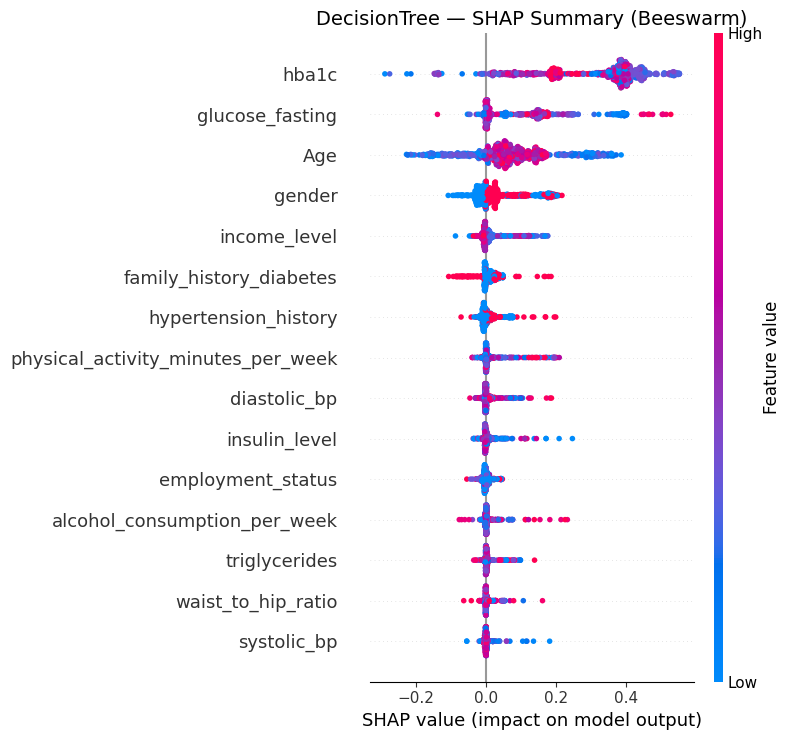

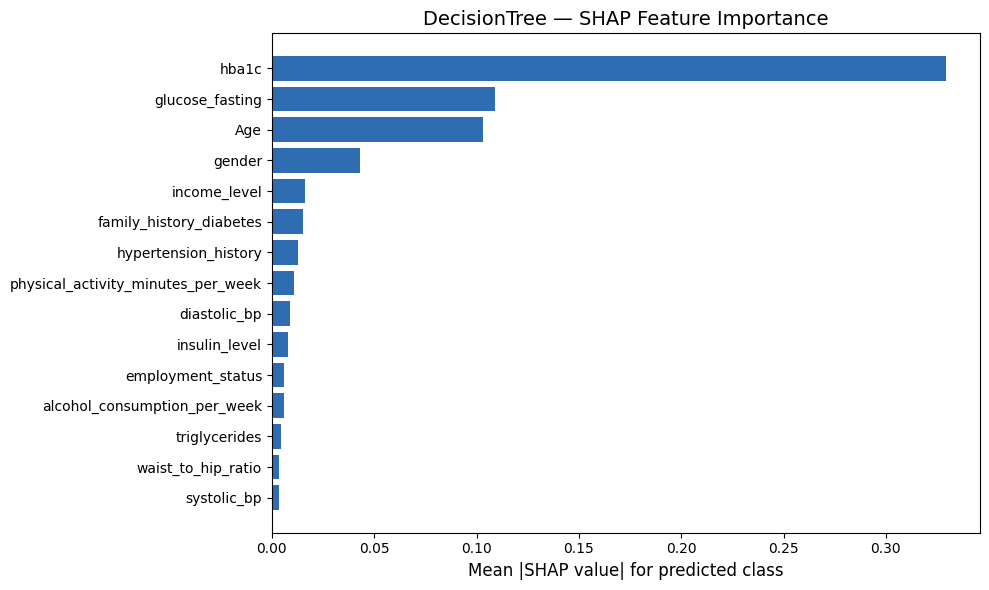

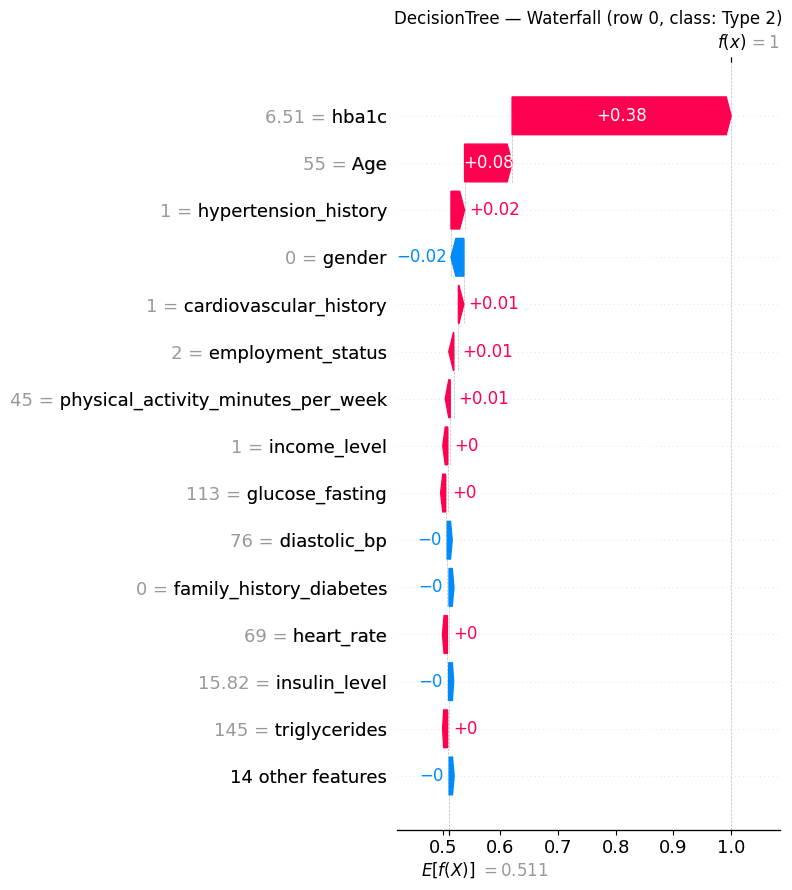


  RandomForest


100%|===================| 4995/5000 [04:25<00:00]        

  SHAP values shape : (1000, 28, 5)
  Unique predictions: [0, 1, 2, 3, 4]


,feature,mean_abs_shap_predicted_class,mean_abs_shap_all_classes,mean_abs_shap_Gestational,mean_abs_shap_No Diabetes,mean_abs_shap_Pre-Diabetes,mean_abs_shap_Type 1,mean_abs_shap_Type 2
18,hba1c,0.2936,0.1256,0.0095,0.1021,0.2395,0.0053,0.2717
15,glucose_fasting,0.0906,0.0452,0.0035,0.0910,0.0805,0.0031,0.0479
0,Age,0.0644,0.0367,0.0558,0.0019,0.0236,0.0348,0.0673
16,glucose_postprandial,0.0495,0.0231,0.0045,0.0172,0.0413,0.0023,0.0504
24,gender,0.0261,0.0160,0.0395,0.0011,0.0092,0.0050,0.0254
19,family_history_diabetes,0.0186,0.0097,0.0060,0.0052,0.0080,0.0054,0.0239
23,income_level,0.0091,0.0055,0.0030,0.0007,0.0049,0.0115,0.0076
8,systolic_bp,0.0080,0.0048,0.0036,0.0006,0.0028,0.0080,0.0092
20,hypertension_history,0.0065,0.0039,0.0057,0.0009,0.0017,0.0028,0.0086
26,employment_status,0.0045,0.0027,0.0026,0.0004,0.0017,0.0026,0.0062


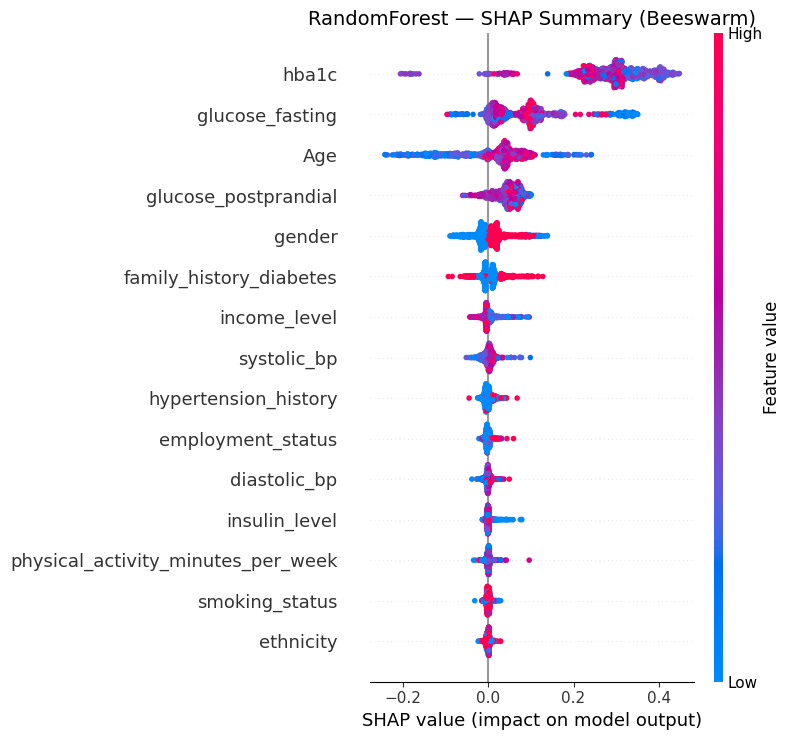

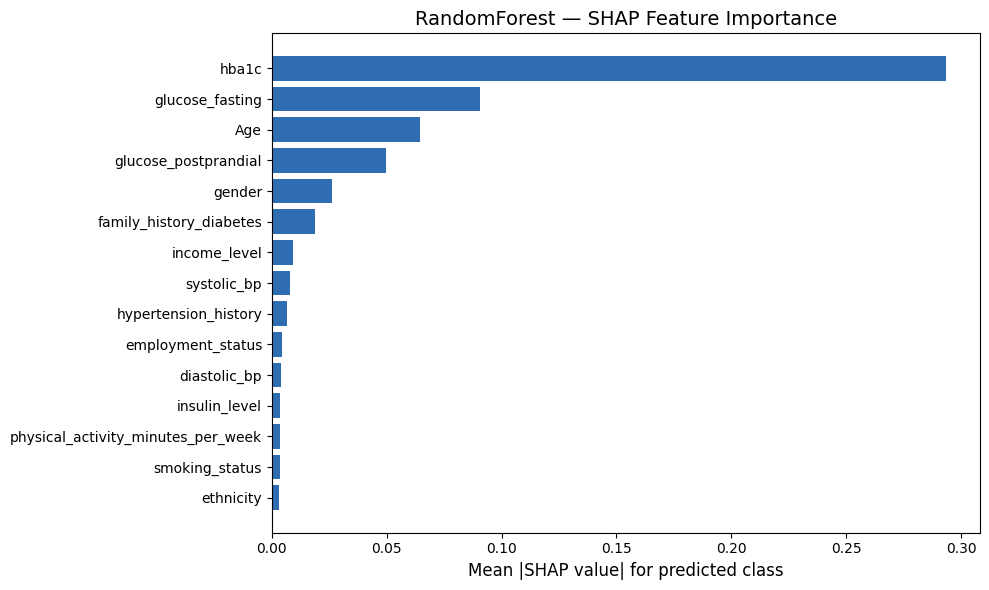

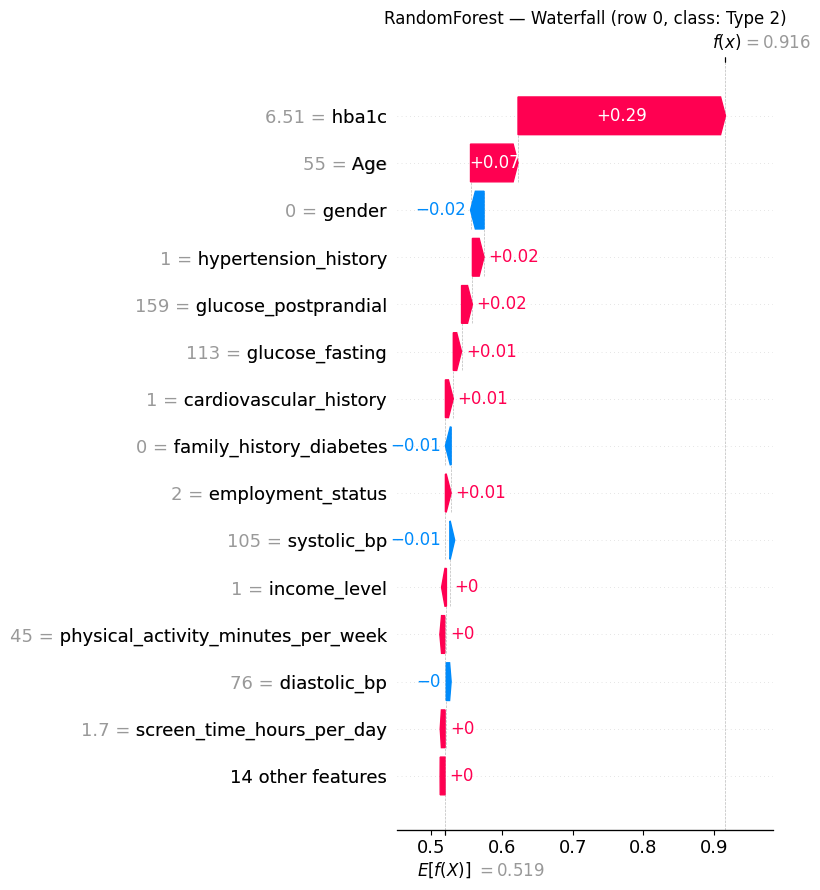


  XGBoost


100%|===================| 4980/5000 [02:49<00:00]        

  SHAP values shape : (1000, 28, 5)
  Unique predictions: [0, 1, 2, 3, 4]


,feature,mean_abs_shap_predicted_class,mean_abs_shap_all_classes,mean_abs_shap_Gestational,mean_abs_shap_No Diabetes,mean_abs_shap_Pre-Diabetes,mean_abs_shap_Type 1,mean_abs_shap_Type 2
18,hba1c,2.6973,1.2973,0.0851,1.3658,3.5200,0.0508,1.4647
15,glucose_fasting,0.8297,0.4873,0.0332,1.2174,0.8388,0.0427,0.3043
0,Age,0.4155,0.6386,1.3466,0.0195,0.0980,1.2309,0.4983
16,glucose_postprandial,0.2125,0.1382,0.0389,0.1983,0.1961,0.0534,0.2043
24,gender,0.1425,0.3608,1.6154,0.0041,0.0329,0.0425,0.1090
19,family_history_diabetes,0.1259,0.0764,0.0046,0.0614,0.0169,0.0706,0.2284
20,hypertension_history,0.1047,0.0731,0.1028,0.0177,0.0166,0.0675,0.1612
8,systolic_bp,0.0896,0.0909,0.0378,0.0087,0.0429,0.2668,0.0981
23,income_level,0.0865,0.0834,0.0179,0.0111,0.0263,0.2617,0.0999
4,sleep_hours_per_day,0.0860,0.0552,0.0335,0.0105,0.0215,0.0937,0.1167


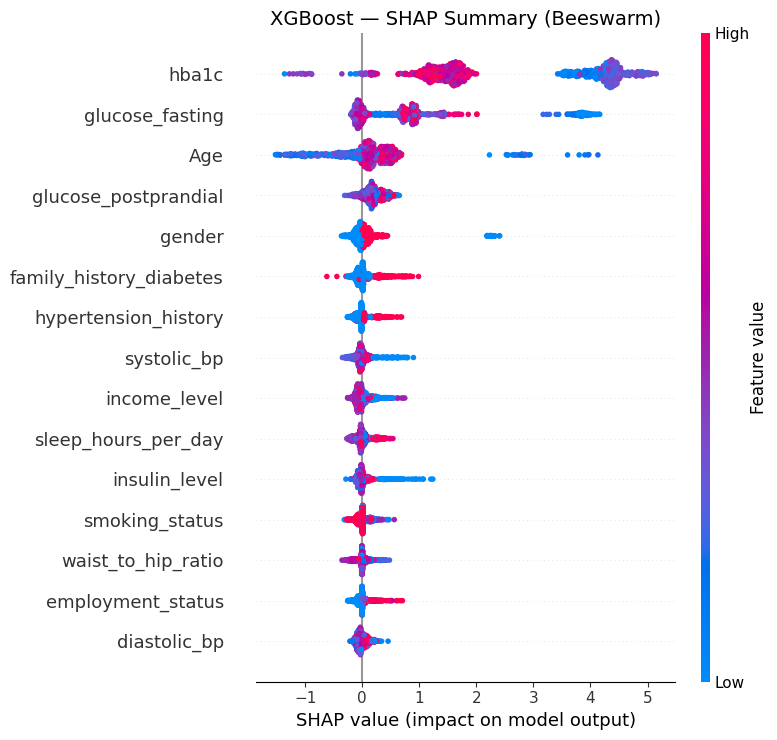

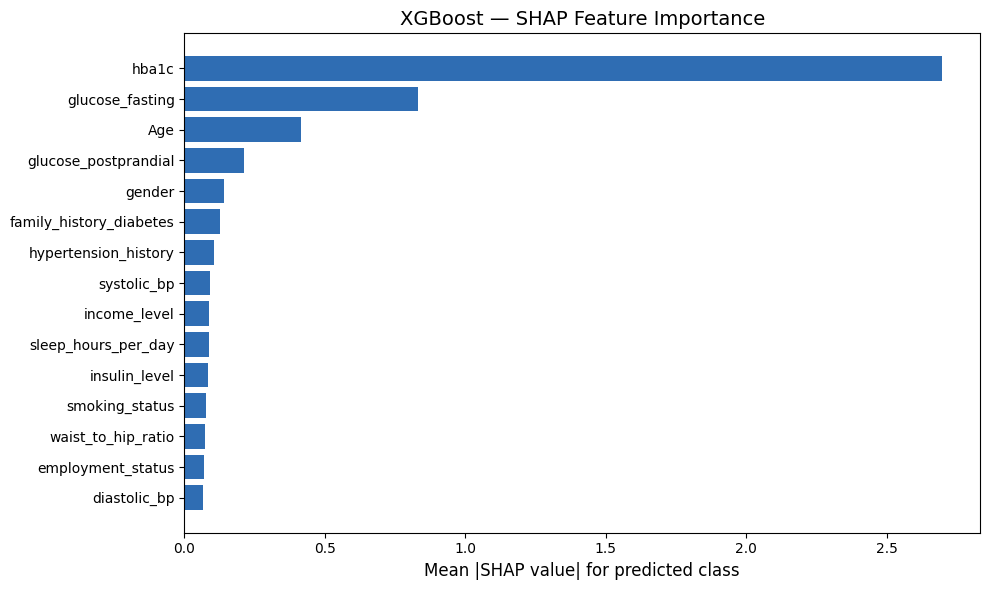

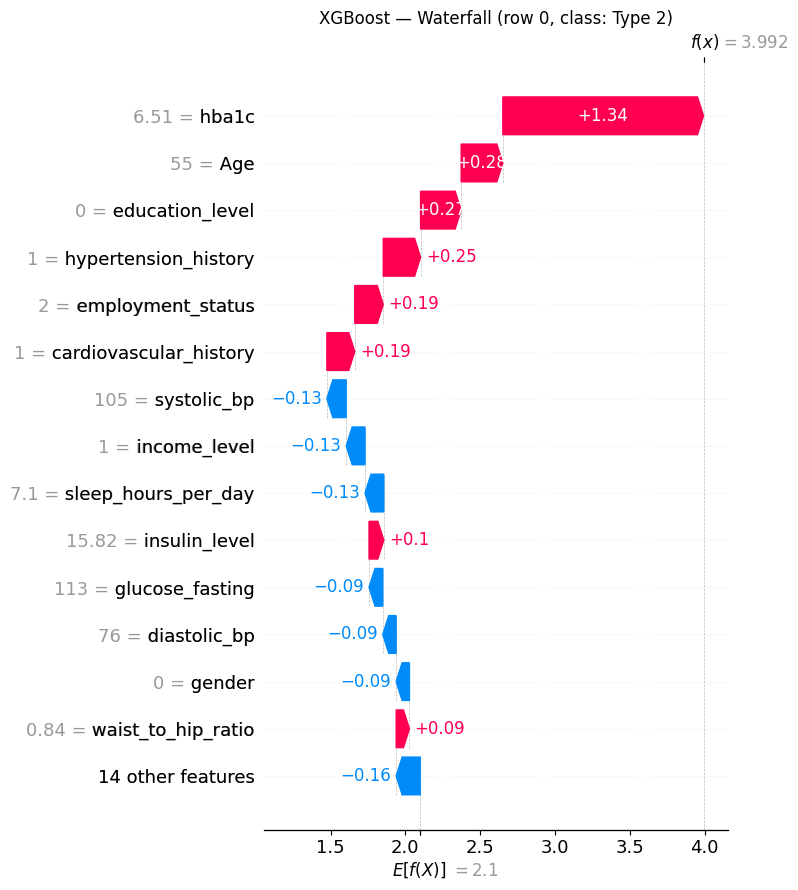


✅ All models complete.


In [5]:
# Storage for the comparison section
all_importance = {}

for model_name in ALL_MODELS:
    model_label = MODEL_LABELS[model_name]

    print("\n" + "=" * 60)
    print(f"  {model_label}")
    print("=" * 60)

    # ── Load model ────────────────────────────────────────────────────────
    model = load_pickle(require_file(MODELS_DIR / MODEL_FILES[model_name]))

    # ── Compute SHAP values ───────────────────────────────────────────────
    explainer           = shap.TreeExplainer(model, data=background)
    values, base_values = compute_shap_values(explainer, X_eval)
    predictions         = np.asarray(model.predict(X_eval)).astype(int)
    projected           = predicted_class_matrix(values, predictions)

    print(f"  SHAP values shape : {values.shape}")
    print(f"  Unique predictions: {np.unique(predictions).tolist()}")

    # ── Feature importance table ──────────────────────────────────────────
    importance_df = build_feature_importance(values, projected, X_eval.columns.tolist(), class_names)
    all_importance[model_name] = importance_df.copy()

    csv_path = DATA_DIR / f"{model_name}_shap_feature_importance.csv"
    importance_df.to_csv(csv_path, index=False)

    display(
        importance_df.head(MAX_DISPLAY)
        .style
        .set_caption(f"{model_label} — Feature Importance")
        .background_gradient(subset=["mean_abs_shap_predicted_class"], cmap="Blues")
        .format({c: "{:.4f}" for c in importance_df.columns if c != "feature"})
    )

    # ── Beeswarm summary plot ─────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(projected, X_eval, plot_type="dot", max_display=MAX_DISPLAY, show=False)
    plt.title(f"{model_label} — SHAP Summary (Beeswarm)", fontsize=14)
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / f"{model_label}_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Bar plot ──────────────────────────────────────────────────────────
    top_feats = importance_df.head(MAX_DISPLAY).iloc[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(top_feats["feature"], top_feats["mean_abs_shap_predicted_class"], color="#2f6db3")
    plt.xlabel("Mean |SHAP value| for predicted class", fontsize=12)
    plt.title(f"{model_label} — SHAP Feature Importance", fontsize=14)
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / f"{model_label}_shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # ── Waterfall plot ────────────────────────────────────────────────────
    if not SKIP_WATERFALL:
        idx = max(0, min(WATERFALL_INDEX, len(X_eval) - 1))

        if values.ndim == 3:
            cls_idx     = int(predictions[idx])
            sample_vals = values[idx, :, cls_idx]
            base_val    = resolve_base_value(base_values, idx, cls_idx)
            cls_label   = class_names[cls_idx]
        else:
            cls_idx     = int(predictions[idx]) if len(class_names) > 1 else 0
            sample_vals = values[idx]
            base_val    = resolve_base_value(base_values, idx, cls_idx)
            cls_label   = class_names[cls_idx] if len(class_names) > cls_idx else "prediction"

        explanation = shap.Explanation(
            values        = sample_vals,
            base_values   = base_val,
            data          = X_eval.iloc[idx].to_numpy(),
            feature_names = X_eval.columns.tolist(),
        )

        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation, max_display=MAX_DISPLAY, show=False)
        plt.title(f"{model_label} — Waterfall (row {idx}, class: {cls_label})", fontsize=12)
        plt.tight_layout()
        plt.savefig(ASSETS_DIR / f"{model_label}_shap_waterfall.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

print("\n✅ All models complete.")

## 5. Side-by-Side Feature Importance Comparison

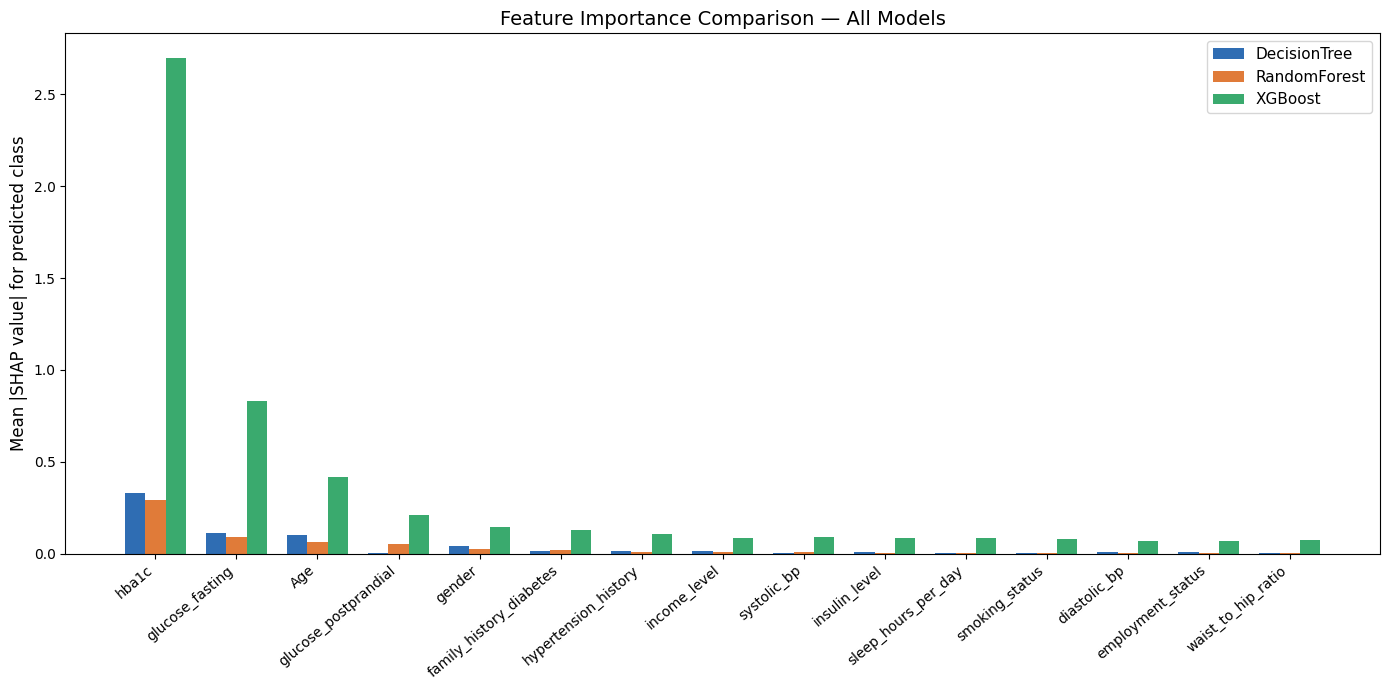

Saved: C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\assets\all_models_shap_comparison.png


In [6]:
# Build merged comparison dataframe
comparison = None
for model_name, imp_df in all_importance.items():
    label = MODEL_LABELS[model_name]
    col   = imp_df[["feature", "mean_abs_shap_predicted_class"]].rename(
        columns={"mean_abs_shap_predicted_class": label}
    )
    comparison = col if comparison is None else comparison.merge(col, on="feature", how="outer")

comparison     = comparison.fillna(0)
label_cols     = [MODEL_LABELS[m] for m in ALL_MODELS]
comparison["avg_importance"] = comparison[label_cols].mean(axis=1)
comparison     = comparison.sort_values("avg_importance", ascending=False).head(MAX_DISPLAY)

# Grouped bar chart
x      = np.arange(len(comparison))
width  = 0.25
colors = ["#2f6db3", "#e07b39", "#3aaa6e"]

fig, ax = plt.subplots(figsize=(14, 7))
for i, (label, color) in enumerate(zip(label_cols, colors)):
    ax.bar(x + i * width, comparison[label], width, label=label, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(comparison["feature"], rotation=40, ha="right", fontsize=10)
ax.set_ylabel("Mean |SHAP value| for predicted class", fontsize=12)
ax.set_title("Feature Importance Comparison — All Models", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "all_models_shap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved: {ASSETS_DIR / 'all_models_shap_comparison.png'}")

## 6. Comparison Table - Top Features by Model

In [7]:
display(
    comparison[["feature"] + label_cols + ["avg_importance"]]
    .reset_index(drop=True)
    .style
    .set_caption("Mean |SHAP| per model — top features ranked by average importance")
    .background_gradient(subset=label_cols + ["avg_importance"], cmap="YlOrRd")
    .format({c: "{:.4f}" for c in label_cols + ["avg_importance"]})
)

,feature,DecisionTree,RandomForest,XGBoost,avg_importance
0,hba1c,0.3295,0.2936,2.6973,1.1068
1,glucose_fasting,0.1092,0.0906,0.8297,0.3432
2,Age,0.1031,0.0644,0.4155,0.1943
3,glucose_postprandial,0.0023,0.0495,0.2125,0.0881
4,gender,0.0429,0.0261,0.1425,0.0705
5,family_history_diabetes,0.0154,0.0186,0.1259,0.0533
6,hypertension_history,0.0129,0.0065,0.1047,0.0414
7,income_level,0.0162,0.0091,0.0865,0.0372
8,systolic_bp,0.0033,0.0080,0.0896,0.0336
9,insulin_level,0.0077,0.0036,0.0849,0.0321


## 7. Summary

In [8]:
print("=" * 60)
print("  SHAP Analysis Complete")
print("=" * 60)
for model_name in ALL_MODELS:
    label = MODEL_LABELS[model_name]
    top   = all_importance[model_name].iloc[0]
    print(f"  {label:<15} → top feature: {top['feature']} ({top['mean_abs_shap_predicted_class']:.4f})")
print("-" * 60)
print(f"  Plots saved to : {ASSETS_DIR}")
print(f"  CSVs saved to  : {DATA_DIR}")
print("=" * 60)

  SHAP Analysis Complete
  DecisionTree    → top feature: hba1c (0.3295)
  RandomForest    → top feature: hba1c (0.2936)
  XGBoost         → top feature: hba1c (2.6973)
------------------------------------------------------------
  Plots saved to : C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\assets
  CSVs saved to  : C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\data


End